
# Goals
- Learn fundamentals of feature selection - for classification task, *by deconstructing the pipeline of C22 paper [ADD paper ref]* 
   - so in next steps - to be able to **replicate the pipeline for anomaly detection**. *Pre-computed feature based models make it easier reason about the model results - more interpretability which translates to more trust from operators/engineers to make results actionable*

**Non-Goals**
- Creating a python module 
- to run the pipeline on any feature set or new datasets

# Imports

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from core import feat_selection as fs

## Data Prep: UCR Clasification data
- load pre-saved features with raw data characterizing features removed
  - Open question: does prefiltering even matter? can the rest of the pipeline remove the raw features
- these features are missing two autocorrelation related features - which can be computed from raw time series (tabled for now)
- [ADD Line about C22 paper removing raw]
  
*C22 paper*: "Features were calculated in Matlab 2017a (a product of The MathWorks, Natick, MA) using hctsa v0.97."

In [8]:
all_tasks = pd.read_parquet(
    Path("../datasets/catch_22/checkpoints/ucr_hctsa_raw_removed.parquet"),
)
print(all_tasks["dataset_name"].nunique())
print(all_tasks.shape)

93
(147198, 6894)


In [9]:
sample_datasets = fs.sample_imbalanced_datasets(all_tasks)
sample_tasks = all_tasks[all_tasks["dataset_name"].isin(sample_datasets.index)]
sample_tasks.shape


57 datasets with minority class <= 30% of samples


(6127, 6894)

### Normalize Features: MinMax
- *C22 paper:* For each dataset, each feature was linearly rescaled to the unit interval. 
- Features with zero range (constant across all time series in a dataset) become NaN

In [10]:
tasks_n = fs.normalize_features(sample_tasks)
print(f"Shape: {tasks_n.shape}")

Shape: (6127, 6893)


## Prefiltering - Remove Invalid Valued Features
- *C22 paper*: Algorithms that produced special-valued outputs on at least one time series,
  in more than 80% of our datasets were excluded: a total of 2101 features

In [11]:
tasks_n_pf = fs.filter_invalid_features(tasks_n.reset_index()) 
tasks_n_pf.shape
# all_tasks_n_pf.to_parquet(Path("../datasets/catch_22/checkpoints/ucr_tasks_feat_norm.parquet"))

Median: 100.0%
Worst:  40.0%
≥99%:   74.7% of survivors
Catch22 In survivors: 20/22
Missing from survivors: []
Not in feature set at all: []


(6127, 6338)

# Methodology Overview

## Performance Scoring

**Accuracy estimation**
[ADD more explanation here]

$N_{\text{CV}} = \min \lbrace 10, \max \lbrack 2, \min_{k=1}^{N_c} ( \sum_{l=1}^{N_{\text{TS}}} \boldsymbol{1}(y_l = k) ) \rbrack \rbrace$

$a_{i,j}(y, \hat{y}, w) = \frac{1}{\sum_{l=1}^{N_{\text{TS}}} w_l} \sum_{l=1}^{N_{\text{TS}}} \mathbf{1}(\hat{y}_l = y_l) w_l$

where $w_l = 1 / \sum_{m=1}^{N_{\text{TS}}} \mathbf{1}(y_m = y_l)$

In [12]:
nfolds = fs.num_of_folds(tasks_n_pf)
perf_scores = fs.calc_per_feat_score(tasks_n_pf, nfolds)


[1/5] dname='AALTDChallenge'


python(28064) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28067) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28069) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28070) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28072) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28073) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28074) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28076) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28078) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28079) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'


### Dataset complexity 

- reflected in performance score densities
- and normalizing the feature accuracy by mean accuracy on task - gives relative accuracy measure among features - helps us answer questions like whether a feature set is consistently better across tasks
  compared to other features. 

In [13]:
fig = fs.plot_score_densities_per_dataset(perf_scores)
fig.show()

### Combined score - C22 features in top performers
- Scores are normalized within the dataset to normalize against the dataset complexity

In [14]:
perf_scores_n, perf_scores_n_c = fs.normalize_and_combine_perf_scores(perf_scores)
perf_scores_n_c.head()

level_1                1.226445
DN_HistogramMode_5     1.576825
DN_HistogramMode_10    1.777395
DN_HistogramMode_20    1.755513
maximum                1.249617
dtype: float64

In [15]:
fig = fs.plot_combined_accuracy(perf_scores_n_c)
fig.show()

# Step 1: Statistical filtering: random performant features
*C22 paper:*  "Given the size and diversity of features in hctsa, we first wanted to deter-
mine whether some features exhibited performance consistent with chance on
this set of classification tasks. 
To estimate a p-value for each feature on each classification task, 
1. (first) we generated *null accuracy distributions*, as i,j (superscript
s incidating ‘shuffeled’), using a permutation-based procedure that involved
1000 repeats of the classification procedure using randomly shuffled class la-
bels, shown in Fig. 1A. From visual inspection, the null distributions were
mostly unimodal and approximately normally distributed and, as expected,
had higher variance on datasets with fewer time series. 
2. (then) Accordingly, we estimated a p-value for each feature-task combination by fitting a Gaussian prob-
ability distribution to the null accuracy distributions, as i,j , as the probability
of the shuffled accuracy being higher than the observed accuracy."

[SIMPLIFY above into 3 short sentences]

## Null Distribution

In [17]:
random_perf_features = pd.read_csv(
      Path('../datasets/catch_22/checkpoints/catch22_insignificant_features_S1.txt'),                                                                                                                                                   
      comment='#',
      header=None,                                                                                                                                                                                        
      names=['p_value', 'feature_name']                                                                                                                                                                   
  )
                                                                                                                                                                                                          
# Get the list of features that performed no better than random
random_feature_names = random_perf_features['feature_name'].values

In [20]:
random_feature_names[:50].to_numpy()

array(['WL_coeffs_db3_4_wb99m', 'WL_coeffs_db3_3_wb99m',
       'WL_coeffs_db3_2_wb99m', 'WL_coeffs_db3_1_wb99m',
       'Y_LocalGlobal_unicg500_iqr',
       'SP_Summaries_welch_rect_linfitloglog_hf_sigrat',
       'SP_Summaries_pgram_hamm_linfitloglog_mf_sigrat',
       'SP_Summaries_pgram_hamm_linfitloglog_hf_sigrat',
       'SP_Summaries_pgram_hamm_linfitloglog_all_sigrat',
       'SP_Summaries_fft_logdev_logstd', 'SP_Summaries_fft_logdev_logiqr',
       'SP_Summaries_fft_logdev_linfitsemilog_all_sigma',
       'SP_Summaries_fft_logdev_linfitsemilog_all_sea1',
       'SP_Summaries_fft_logdev_linfitsemilog_mf_a2',
       'SP_Summaries_fft_logdev_linfitloglog_mf_sigrat',
       'SP_Summaries_fft_logdev_linfitloglog_mf_sigma',
       'SP_Summaries_fft_logdev_linfitloglog_mf_sea1',
       'SP_Summaries_fft_logdev_linfitloglog_mf_a2',
       'SP_Summaries_fft_logdev_linfitloglog_hf_sigrat',
       'SP_Summaries_fft_logdev_linfitloglog_hf_sigma',
       'SP_Summaries_fft_logdev_linfitlogl

In [ ]:
sampled_features = fs.CATCH22 + list(random_feature_names[:50])
sampled_features = [col for col in tasks_n_pf.columns if col in sampled_features] # make sure that the feature is present in the dataset

In [25]:

null_scores = fs.calc_score_null_dist(tasks_n_pf, nfolds, features=sampled_features, n_permutations=200)
null_scores


[1/200]
[1/5] dname='AALTDChallenge'


python(30109) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30110) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30111) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30112) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30113) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30114) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30115) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30116) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(30118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'
[2/200]
[1/5] dname='AALTDChallenge'
[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'
[3/200]
[1/5] dname='AALTDChallenge'
[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'
[4/200]
[1/5] dname='AALTDChallenge'
[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'
[5/200]
[1/5] dname='AALTDChallenge'
[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasiveFetalECGThorax1'
[6/200]
[1/5] dname='AALTDChallenge'
[2/5] dname='CinCECGtorso'
[3/5] dname='ECGMeditation'
[4/5] dname='MiddlePhalanxOutlineAgeGroup'
[5/5] dname='NonInvasi

[                              DN_HistogramMode_5  DN_HistogramMode_10  \
 dataset_name                                                            
 AALTDChallenge                          0.180952             0.169048   
 CinCECGtorso                            0.256885             0.255675   
 ECGMeditation                           0.166667             0.333333   
 MiddlePhalanxOutlineAgeGroup            0.321593             0.346428   
 NonInvasiveFetalECGThorax1              0.030304             0.025955   
 
                               CO_HistogramAMI_even_2_5  \
 dataset_name                                             
 AALTDChallenge                                0.123016   
 CinCECGtorso                                  0.249067   
 ECGMeditation                                 0.229167   
 MiddlePhalanxOutlineAgeGroup                  0.307913   
 NonInvasiveFetalECGThorax1                    0.025410   
 
                               IN_AutoMutualInfoStats_40_gaussian

In [27]:
import pickle
with open(Path("../datasets/catch_22/checkpoints/sampled_null_scores.pkl"), "wb") as f:
    pickle.dump(null_scores, f)

In [31]:

perf_scores[sampled_features].shape, null_scores[0].shape

((5, 66), (5, 66))

In [32]:
perf_scores[sampled_features].head()

,DN_HistogramMode_5,DN_HistogramMode_10,CO_HistogramAMI_even_2_5,IN_AutoMutualInfoStats_40_gaussian_fmmi,CO_trev_1_num,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0.01,CO_Embed2_Dist_tau_d_expfit_meandiff,FC_LocalSimple_mean1_tauresrat,FC_LocalSimple_mean3_stderr,...,NL_MS_nlpe_fnn_mi_ac3n,NL_MS_nlpe_fnn_mi_acmnd0,MS_shannon_2_1t10_maxent,MS_shannon_3_1t10_maxent,MS_shannon_3_1t10_stdent,MS_shannon_4_1t10_maxent,MS_shannon_4_1t10_stdent,MF_armax_3_1_05_1_lastimprovement,MF_armax_3_1_05_1_ac3n,MD_hrv_classic_pnn40
dataset_name,,,,,,,,,,,,,,,,,,,,,
AALTDChallenge,0.316667,0.302381,0.264286,0.383333,0.155556,0.280952,0.270635,0.218254,0.257143,0.348413,...,0.161905,0.156349,0.146032,0.149206,0.194444,0.133333,0.192063,0.180952,0.175397,0.300000
CinCECGtorso,0.504187,0.521468,0.468532,0.489107,0.432480,0.436290,0.760496,0.614524,0.454563,0.524623,...,0.338810,0.335179,0.265159,0.243115,0.294365,0.255099,0.260516,0.258968,0.432698,0.488552
ECGMeditation,0.583333,0.291667,0.500000,0.520833,0.541667,0.479167,0.645833,0.541667,0.604167,0.437500,...,0.333333,0.229167,0.291667,0.458333,0.437500,0.437500,0.312500,0.479167,0.541667,0.312500
MiddlePhalanxOutlineAgeGroup,0.579357,0.650922,0.477191,0.563558,0.567826,0.630588,0.363752,0.588352,0.664407,0.580083,...,0.327366,0.340524,0.383351,0.485305,0.428842,0.375203,0.378725,0.357190,0.360960,0.607063
NonInvasiveFetalECGThorax1,0.170751,0.283484,0.202476,0.118454,0.097159,0.131927,0.130479,0.252046,0.180333,0.118761,...,0.027540,0.030023,0.026563,0.023554,0.021418,0.024987,0.026243,0.025581,0.040675,0.122376


In [33]:

p_values = fs.calc_p_values(perf_scores[sampled_features], null_scores)


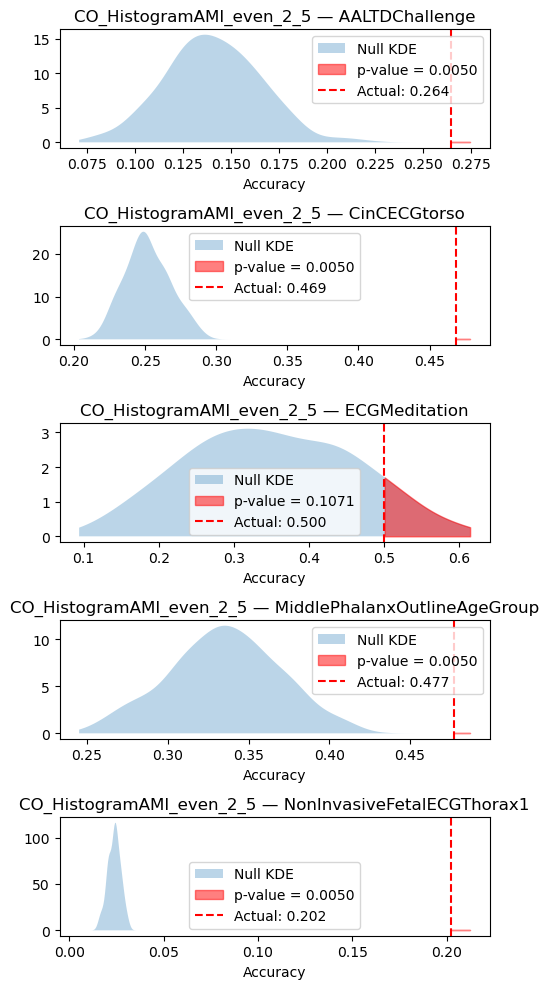

In [38]:

fig = fs.plot_null_distribution(sampled_features[2], perf_scores, null_scores, p_values)

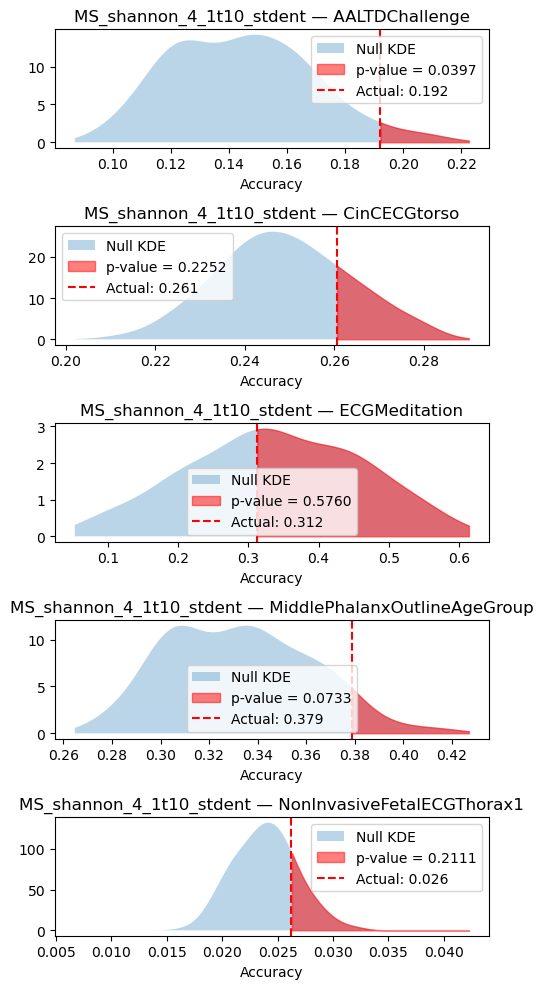

In [37]:
fig = fs.plot_null_distribution(sampled_features[-4], perf_scores, null_scores, p_values)

## Fisher Test
 We ran ran the same statistical test (e.g., "is feature X useful for classification?") across many independent tasks. Now you have a collection of p-values for the same feature:

  Feature "mean_abs_change":
    Task 1 → p = 0.03
    Task 2 → p = 0.12
    Task 3 → p = 0.08
    Task 4 → p = 0.45
    ...
Fisher test is used to combine p-values of a given feature (across all tasks).

The core intuition:*
- Permuting the labels of the dataset breaks the relationship between the feature and labels. If a feature is useless, then even after permutation, it can give high score by random chance. So $P(X> actual\_score)$ can be arbirtrarily high, where X is distribution of scores under null hypothesis. 
Null Hypothesis: Feature has no meaninful relationship with the , which implies that p-value(= P(X > actual_score)) can be arbitrarily high - i.e. it follows Unif[0,1] distribution (since probability min=0 and max=1).
-  That means -log(p) follows an exponential distribution, and -2 * log(p) follows a chi-squared 
- Fisher's Test combines the p-values 

## Fisher Test - p_values -> combined values
The problem it solves

  You ran the same statistical test (e.g., "is feature X useful for classification?") across many independent tasks. Now you have a collection of p-values for the same feature:

  Feature "mean_abs_change":
    Task 1 → p = 0.03
    Task 2 → p = 0.12
    Task 3 → p = 0.08
    Task 4 → p = 0.45
    ...

  No single p-value is the full picture. You want one combined answer: is this feature statistically useful overall?

  The core intuition

  Under the null hypothesis (feature is useless), p-values are uniformly distributed on [0, 1]. That means -log(p) follows an exponential distribution, and -2 * log(p) follows a chi-squared distribution with 2 degrees of freedom.

  Fisher's insight: if you sum independent chi-squared variables, you get another chi-squared variable. So for k independent tests:

  X² = -2 * Σ log(pᵢ)      (sum over k tasks)

  This follows a chi-squared distribution with 2k degrees of freedom under the null.

  Why it works intuitively

  - Small p-values → large -log(p) → inflates the sum
  - If many tasks give small p-values, the sum becomes improbably large under the null
  - Even if no single task is "significant" alone, consistent evidence across tasks accumulates

  In your example: p = 0.03, 0.12, 0.08, 0.45 — none are slam dunks individually, but together they might be.


**Holm-Bonferroni Correction**

  The problem

  You just ran Fisher's test for every feature (say 7000+ hctsa features). Each one gives a combined p-value. If you threshold at 0.05, you'd expect ~350 false positives purely by chance (5% of 7000). That's the multiple hypothesis testing problem.

  How it works

  1. Sort all your combined p-values from smallest to largest
  2. Compare each one against a progressively relaxing threshold:
    - Smallest p-value must beat 0.05 / N (N = number of features)
    - Second smallest must beat 0.05 / (N-1)
    - Third must beat 0.05 / (N-2)
    - ...and so on
  3. Stop at the first feature that fails its threshold. That feature and all larger p-values are deemed not significant.

  Why not plain Bonferroni?

  Plain Bonferroni uses 0.05 / N for every feature — very conservative, throws away real signal. Holm-Bonferroni is strictly more powerful: it starts just as strict but relaxes the threshold as you confirm more features, so you keep more genuinely
  useful features while still controlling false positives.

  Intuition

  Think of it as a gatekeeper. The first feature has to clear the hardest bar (because if even the best feature is a fluke, you're in trouble). But once you've confirmed the best ones are real, the remaining features don't need to be held to quite as
  high a standard.
    In code

  from statsmodels.stats.multitest import multipletests

  rejected, corrected_pvals, _, _ = multipletests(combined_pvalues, alpha=0.05, method='holm')

  - rejected: boolean array — True means feature passed the filter
  - corrected_pvals: adjusted p-values you can threshold directly

  Features where rejected == True survive the statistical prefiltering stage.

# Step 2a: Prep for Performance Filtering

"From the features that performed significantly better than chance, we selected a subset of $\beta$ high-performing features by ranking them by their combined normalized accuracy $a_{n,c}$ (Fig. 1B), comparing values in the range $100 \leq \beta \leq 1000$".

Verify: hundreds of features survive; C22 features are among them.Paper gets ~710 survivors.

In [ ]:
# calculate and store feature performances for all features??

## Perf Score Analysis

# Apendix

In [ ]:

random_perf_features = pd.read_csv(
      Path('../datasets/catch_22/checkpoints/catch22_insignificant_features_S1.txt'),                                                                                                                                                   
      comment='#',
      header=None,                                                                                                                                                                                        
      names=['p_value', 'feature_name']                                                                                                                                                                   
  )
                                                                                                                                                                                                          
# Get the list of features that performed no better than random
random_feature_names = random_perf_features['feature_name'].values

# Filter out random-performing features from the combined scores
perf_scores_wo_random = perf_scores_norm_comb[~perf_scores_norm_comb.index.isin(random_feature_names)]

print(f"Total features: {len(perf_scores_norm_comb)}")
print(f"Random/insignificant features removed: {len(random_feature_names)}")
print(f"Features remaining: {len(perf_scores_wo_random)}")

perf_thresh = perf_scores_norm_comb.mean() + perf_scores_norm_comb.std()

# Combined accuracy KDE
vals = perf_scores_norm_comb.dropna().values
#vals = (vals - vals.mean())/vals.std()
kde = gaussian_kde(vals)
# x_range = np.linspace(vals.min(), vals.max(), 500)
x_range = np.linspace(0, 2, 500)
y = kde(x_range)
# mean subtracted to reproduce Fig 3A from paper
x_range = (x_range - x_range.mean()) #/x_range.std()
#y /= y.max()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_range, y=y,
    mode="lines",
    line=dict(color="red", width=2.5),
    name="Combined Accuracy",
))
fig.update_layout(
    xaxis_title="Normalized Accuracy",
    yaxis_title="Normalized Density",
    xaxis=dict(dtick=0.2),
    yaxis=dict(dtick=0.5, range=[0,3.7]),
    width=1000,
    height=600,
    showlegend=True,
)

# mean subtracted to reproduce Fig 3A from paper
fig.add_vline(perf_thresh - perf_scores_norm_comb.mean(), line_dash="dash")
fig.show()

top_performers = perf_scores_norm_comb[perf_scores_norm_comb >= perf_thresh]
print(perf_thresh,perf_scores_norm_comb.shape[0], top_performers.shape[0])

# Check that C22 features are present in top_performers
c22_in_top = [f for f in fs.CATCH22 if f in perf_scores_wo_random.index]
c22_missing = [f for f in fs.CATCH22 if f not in perf_scores_wo_random.index]

print(f"C22 features in perf_scores_wo_random: {len(c22_in_top)}/{len(fs.CATCH22)}")
if c22_missing:
    print(f"Missing from perf_scores_wo_random: {c22_missing}")
else:
    print("All C22 features are present in perf_scores_wo_random.")

In [ ]:

perf_scores_norm = new_perf_scores.subtract(new_perf_scores.mean(axis=1), axis=0).div(new_perf_scores.std(axis=1), axis=0)
corr = perf_scores_norm[top_performers.index].corr()


# Hierarchical clustering to order features (as in catch22 paper)
dist = 1 - corr
condensed_dist = squareform(dist, checks=False)
Z = linkage(condensed_dist, method="complete")
order = leaves_list(Z)

# Reorder correlation matrix by cluster order
corr_ordered = corr.iloc[order, order]

# Discrete colorscale with 5 bins: 0.6, 0.7, 0.8, 0.9, 1.0
colorscale = [
    [0.0,  "#fff5eb"],  # 0.6
    [0.25, "#fff5eb"],
    [0.25, "#fdbe85"],  # 0.7
    [0.5,  "#fdbe85"],
    [0.5,  "#fd8d3c"],  # 0.8
    [0.75, "#fd8d3c"],
    [0.75, "#e6550d"],  # 0.9
    [1.0,  "#e6550d"],  # 1.0
]

fig = go.Figure(data=go.Heatmap(
    z=corr_ordered.values,
    zmin=0.6, zmax=1.0,
    colorscale=colorscale,
    colorbar=dict(
        title="Pearson correlation",
        tickvals=[0.65, 0.75, 0.85, 0.95],
        ticktext=["0.6", "0.7", "0.8", "0.9"],
    ),
))
fig.update_layout(
    width=700, height=700,
    title="Fig 3C: Correlation matrix of top-performing features",
    xaxis=dict(title="features", showticklabels=False),
    yaxis=dict(title="features", showticklabels=False, autorange="reversed"),
)
fig.show()